# L96 sensitivity evaluation

This notebook evaluates and visualizes the sensitivity of the full L96 system to $N_{\mathrm{ens}}$ perturbations of $N_{\mathrm{init}}$ perfect initial conditions.

## Metrics

### Perturbed settings $(N_{init} \times N_{ens})$

**Expected value**: 
$$
\mu_k(t)  = \mathbb{E}_{i,j} \left[ X_{i,j,k}(t) \right]
$$

**Variance**: 
$$
V_k(t)  = \operatorname{Var}_{i,j } \left( X_{i,j,k}(t) \right)
$$

**Median**: 
$$
M_k(t)  = \mathrm{median}_{i,j} \left(  X_{i,j,k}(t) \right)
$$

**IQR**: 
$$
\begin{aligned}
q_{0.25, k}(t)  &= q_{0.25, i,j} \left( X_{i,j,k}(t) \right) \\
q_{0.75, k}(t)  &= q_{0.75, i,j} \left(  X_{i,j,k}(t) \right)
\\
\mathrm{IQR}_k(t)  &= q_{0.75, k}(t) - q_{0.25, k}(t)
\end{aligned}
$$

**Average pairwise distance**:  
This metric consider the full state vector $\mathbf{X} \in \mathbb{R}^K$.  
$$
\begin{aligned}
d_{i,j \ell}(t) &=  \left\| \mathbf{X}_{i,j}(t) - \mathbf{X}_{i,\ell}(t) \right\|_2 
= \left( \sum_{k} \left( X_{i,j,k}(t) - X_{i,\ell,k}(t) \right)^2 \right)^{1/2}
\\
\mathrm{apd}(t)  &= \frac{1}{N_{\mathrm{init}} } \sum_i 
\frac{2}{N_{\mathrm{ens}} (N_{\mathrm{ens}}-1)}
\sum_{j \leq \ell } d_{i,j \ell}(t) 
\end{aligned}
$$

with indices 
$$
\begin{aligned}
i &= 1, \ldots, N_{\mathrm{init}} \\
j &= 1, \ldots, N_{\mathrm{ens}} \\
\ell &= j, \ldots, N_{\mathrm{ens}} \\
\end{aligned}
$$

The above metrics are named `<metric>_total_tk`. The notebook also contains computation for corresponding metrics, where $j$ is averaged. These are denoted by `<metric>_i_tk`.

### Perfect settings $(N_{init})$

**Expected value**: 
$$
\mu^p_k(t)  = \mathbb{E}_{i} \left[ X_{i, k}(t) \right]
$$

**Variance**=: 
$$
V^p_k(t)  = \operatorname{Var}_i \left(  X_{i,k}(t)  \right)
$$

**Median**=: 
$$
M^p_k(t)  = \mathrm{median}_i \left( X_{i,k}(t)  \right)
$$

**IQR**=: 
$$
\begin{aligned}
q^p_{0.25, k}(t)  &= q_{0.25, i} \left(  X_{i,k}(t)  \right) \\
q^p_{0.75, k}(t)  &= q_{0.75, i} \left(  X_{i,j,k}(t) \right)
\\
\mathrm{IQR}^p_k(t)  &= q^p_{0.75, k}(t) - q^p_{0.25, k}(t)
\end{aligned}
$$


In [2]:
%autoreload

In [3]:
import sys
from pathlib import Path

# resolve project root (two levels up from this notebook)
PROJECT_ROOT = Path.cwd().resolve().parents[1]

SRC_DIR = PROJECT_ROOT / "src"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for p in (SRC_DIR, NOTEBOOKS_DIR):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

In [4]:
import gc
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.patches import Patch
import matplotlib.transforms as transforms
from scipy.spatial.distance import pdist

from ensemble.storage import load_output_l96_ensemble
from notebook_utils import generate_sweep_dict_list, revert_sweep_name
from utils.config import ConfigL96
from utils.sweep_utils import get_sweep_name

## Load data

In [5]:
results_dir = PROJECT_ROOT / "results"
l96_base_dir = results_dir / "ensemble_l96"
experiment_dirs = ["sensitivity", "short"]

n_init_states = 300
n_ens_members = 20
n_models = 1

output_subdir = ""

paper_figures_dir = (
    PROJECT_ROOT / "paper" / "figures" / output_subdir / "ensemble_l96_sensitivity"
)
paper_figures_dir.mkdir(parents=True, exist_ok=True)

# Save computed dataframes to avoid recomputation
output_dir = (
    PROJECT_ROOT
    / "notebooks"
    / "evaluation"
    / "output"
    / output_subdir
    / "ensemble_evaluation"
    / "l96_sensitivity"
)
output_dir.mkdir(parents=True, exist_ok=True)

In [6]:
def load_yaml(file_path):
    with open(file_path, "r") as f:
        return yaml.safe_load(f)

### L96 data

In [7]:
l96_data = {}

for exp_dir in experiment_dirs:
    l96_dir = l96_base_dir / exp_dir

    sweep_path = l96_dir / "sweep.yaml"
    sweep = load_yaml(sweep_path)

    l96_data[exp_dir] = {"sweep": sweep}
    t = None
    DEFAULT_SWEEP_KEY = "default"

    print(f"Loading data from {l96_dir.name}...")

    for s in generate_sweep_dict_list(sweep):
        sweep_name = get_sweep_name(s)
        out_path = l96_dir / sweep_name

        config_path = out_path / "config.yaml"
        config = ConfigL96(config_path, eval_mode=True)

        assert config.n_init_states == n_init_states
        assert config.n_models == n_models
        if exp_dir == "sensitivity":
            assert config.n_ens_members == n_ens_members
            assert config.init_states_type == "perturbed"

        else:
            assert config.n_ens_members == 1
            assert config.init_states_type == "perfect"

        print(f"  Loading L96 output for sweep: {sweep_name}...")

        x, t_curr = load_output_l96_ensemble(
            config.output_dir(out_path), load_y=False, backend=config.load_backend
        )
        N, M, T, K = x.shape
        if M == 1:
            # reduce singleton ensemble dimension
            x = x[:, 0, :, :]

        if t is None:
            t = t_curr
        else:
            assert np.allclose(t, t_curr)

        sweep_key = sweep_name if sweep_name != "" else DEFAULT_SWEEP_KEY
        l96_data[exp_dir][sweep_key] = {"x": x, "si": config.si}
print("Done.")

Loading data from sensitivity...
  Loading L96 output for sweep: ...
Loading data from short...
  Loading L96 output for sweep: ...
Done.


In [8]:
for exp_dir in experiment_dirs:
    print(f"{exp_dir}: {l96_data[exp_dir][DEFAULT_SWEEP_KEY]['x'].shape}")

sensitivity: (300, 20, 2001, 8)
short: (300, 2001, 8)


## Compute spread metrics

In [9]:
def _to_numpy(x):
    # zarr slices are already numpy-ish; dask/xarray might need compute/values
    if hasattr(x, "compute"):
        x = x.compute()
    if hasattr(x, "values"):
        x = x.values
    return np.asarray(x)


def _format_mmss(seconds):
    m, s = divmod(int(seconds), 60)
    return f"{m:02d}:{s:02d}"

In [10]:
def compute_metrics_perturbed(x_arr):
    """
    x_arr: [N_init, N_ens, T, K]

    Returns (all shape [T, K]):
        var_total_tk
        std_total_tk,
        mean_total_tk,
        var_i_tk,
        std_i_tk,
        median_i_tk,
        q25_i_tk,
        q75_i_tk,
        iqr_i_tk,
        median_total_tk,
        q25_total_tk,
        q75_total_tk,
        iqr_total_tk,
        sigma_clim,
        avg_pairwise_i_tk,
        std_pairwise_i_tk,
    """
    x_arr = _to_numpy(x_arr)
    N_init, N_ens, T, K = x_arr.shape

    var_total_tk = np.var(x_arr, axis=(0, 1))  # [T,K]
    std_total_tk = np.sqrt(var_total_tk)

    mean_total_tk = np.mean(x_arr, axis=(0, 1))  # [T,K]

    mean_j = np.mean(x_arr, axis=1)  # [N_init,T,K]
    var_i_tk = np.var(mean_j, axis=0)  # [T,K]
    std_i_tk = np.sqrt(var_i_tk)  # [T,K]

    median_i_tk = np.median(x_arr, axis=(0, 1))
    q25_i_tk = np.quantile(mean_j, 0.25, axis=0)
    q75_i_tk = np.quantile(mean_j, 0.75, axis=0)
    iqr_i_tk = q75_i_tk - q25_i_tk

    median_total_tk = np.median(x_arr, axis=(0, 1))
    q_25_total_tk = np.quantile(x_arr, 0.25, axis=(0, 1))
    q_75_total_tk = np.quantile(x_arr, 0.75, axis=(0, 1))
    iqr_total_tk = q_75_total_tk - q_25_total_tk

    sigma_clim = np.std(x_arr)

    avg_pairwise_i_tk = np.zeros((T, K))
    std_pairwise_i_tk = np.zeros((T, K))

    for t in range(T):
        x_t = x_arr[:, :, t, :]  # [N_init, N_ens, K]

        dists_all = []

        for i in range(N_init):
            ens_slice = x_t[i]  # [N_ens, K]
            dists = pdist(ens_slice, metric="euclidean")
            dists_all.append(dists)

        dists_all = np.concatenate(dists_all)

        avg_pairwise_i_tk[t] = np.mean(dists_all)
        std_pairwise_i_tk[t] = np.std(dists_all)

    return {
        "var_total_tk": var_total_tk,
        "std_total_tk": std_total_tk,
        "mean_total_tk": mean_total_tk,
        "var_i_tk": var_i_tk,
        "std_i_tk": std_i_tk,
        "median_i_tk": median_i_tk,
        "q25_i_tk": q25_i_tk,
        "q75_i_tk": q75_i_tk,
        "iqr_i_tk": iqr_i_tk,
        "median_total_tk": median_total_tk,
        "q25_total_tk": q_25_total_tk,
        "q75_total_tk": q_75_total_tk,
        "iqr_total_tk": iqr_total_tk,
        "sigma_clim": sigma_clim,
        "avg_pairwise_i_tk": avg_pairwise_i_tk,
        "std_pairwise_i_tk": std_pairwise_i_tk,
    }

In [11]:
def compute_metrics_perfect(x_arr):
    """
    x_arr: [N_init, T, K]

    Returns (all shape [T, K]):
        mean_i_tk,
        var_i_tk,
        std_i_tk,
        median_i_tk,
        q25_i_tk,
        q75_i_tk,
        iqr_i_tk,
        sigma_clim,
    """
    x_arr = _to_numpy(x_arr)
    N_init, T, K = x_arr.shape

    mean_i_tk = np.mean(x_arr, axis=0)  # [T, K]
    var_i_tk = np.var(x_arr, axis=0)  # [T, K]
    std_i_tk = np.sqrt(var_i_tk)

    median_i_tk = np.median(x_arr, axis=0)  # [T, K]
    q25_i_tk = np.quantile(x_arr, 0.25, axis=0)  # [T, K]
    q75_i_tk = np.quantile(x_arr, 0.75, axis=0)  # [T, K]
    iqr_i_tk = q75_i_tk - q25_i_tk

    sigma_clim = np.std(x_arr)

    return {
        "mean_i_tk": mean_i_tk,
        "var_i_tk": var_i_tk,
        "std_i_tk": std_i_tk,
        "median_i_tk": median_i_tk,
        "q25_i_tk": q25_i_tk,
        "q75_i_tk": q75_i_tk,
        "iqr_i_tk": iqr_i_tk,
        "sigma_clim": sigma_clim,
    }

In [12]:
def build_metrics_df(l96_data):
    """ """

    rows = []

    for exp_dir, data_dict in l96_data.items():
        print(f"  Processing exp_dir {exp_dir}...")
        for sweep_key, sweep_dict in data_dict.items():
            if sweep_key == "sweep":
                continue
            if exp_dir == "sensitivity":
                metrics = compute_metrics_perturbed(sweep_dict["x"])
            else:
                metrics = compute_metrics_perfect(sweep_dict["x"])

            meta = revert_sweep_name(sweep_key, sweep_dict.get("sweep", {}))
            row = {
                "type": "perfect" if exp_dir == "short" else "perturbed",
                **meta,
                **metrics,
                "si": sweep_dict["si"],
            }
            rows.append(row)

            gc.collect()
    return pd.DataFrame(rows)

In [13]:
t0 = time.perf_counter()
print("Computing metrics for all experiments...")
metrics_df = build_metrics_df(l96_data)

elapsed = time.perf_counter() - t0
print(f"Metric computation done in {_format_mmss(elapsed)}")

print("\nSaving metrics DataFrame to pickle...")
metrics_df.to_pickle(output_dir / "metrics_df.pkl")
print("Done.")

Computing metrics for all experiments...
  Processing exp_dir sensitivity...
  Processing exp_dir short...
Metric computation done in 00:19

Saving metrics DataFrame to pickle...
Done.


In [14]:
# Load
# metrics_df = pd.read_pickle(output_dir / "metrics_df.pkl")

In [15]:
metrics_df.columns

Index(['type', 'var_total_tk', 'std_total_tk', 'mean_total_tk', 'var_i_tk',
       'std_i_tk', 'median_i_tk', 'q25_i_tk', 'q75_i_tk', 'iqr_i_tk',
       'median_total_tk', 'q25_total_tk', 'q75_total_tk', 'iqr_total_tk',
       'sigma_clim', 'avg_pairwise_i_tk', 'std_pairwise_i_tk', 'si',
       'mean_i_tk'],
      dtype='object')

## Plot metrics

In [16]:
# -----------------------------
# labels + colors
# -----------------------------
def parse_label(name, kind):
    """
    name: metric key (e.g. 'std_i_tk', 'mean_total_tk', ...)
    kind: 'perturbed' -> $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$ | 'perfect' -> $N_{\mathrm{init}}$
    """

    if kind == "perturbed":
        ens_config = r"$(N_{\mathrm{init}} \times N_{\mathrm{ens}})$"
    else:
        ens_config = r"$N_{\mathrm{init}}$"

    mapping = {
        # means
        "mean_total_tk": f"Mean {ens_config}",
        "mean_i_tk": f"Mean {ens_config}",
        # spread over i (of ensemble mean for perturbed; plain i for perfect)
        "std_i_tk": f"Std. {ens_config}",
        "var_i_tk": f"Variance {ens_config}",
        # spread over (i,j) for perturbed
        "std_total_tk": f"Total std. {ens_config}",
        "var_total_tk": f"Total variance {ens_config}",
        # quantiles over i
        "median_i_tk": f"Median {ens_config}",
        "q25_i_tk": f"25th percentile {ens_config}",
        "q75_i_tk": f"75th percentile {ens_config}",
        "iqr_i_tk": f"IQR {ens_config} (75th-25th)",
        # quantiles over total (i,j) for perturbed
        "median_total_tk": f"Median {ens_config}",
        "q25_total_tk": f"25th percentile {ens_config}",
        "q75_total_tk": f"75th percentile {ens_config}",
        "iqr_total_tk": f"IQR {ens_config} (75th-25th)",
        # distances
        "avg_pairwise_i_tk": f"Avg. pw. dist. {ens_config}",
        "std_pairwise_i_tk": f"Std. pw. dist. {ens_config}",
        # global
        "sigma_clim": r"$\sigma_{\mathrm{clim}}$",
    }

    return mapping.get(name, name.replace("_", " ").title())


def colors(name, n_cols=7):
    pal = sns.color_palette("colorblind", n_cols)
    mapping = {
        # mean
        "mean_total_tk": pal[0],
        "mean_i_tk": pal[0],
        # std/var
        "std_i_tk": pal[1],
        "std_total_tk": pal[1],
        "var_i_tk": pal[1],
        "var_total_tk": pal[1],
        # median/IQR/quantiles
        "median_i_tk": pal[2],
        "median_total_tk": pal[2],
        "iqr_i_tk": pal[3],
        "iqr_total_tk": pal[3],
        "q25_i_tk": pal[6],
        "q75_i_tk": pal[6],
        "q25_total_tk": pal[6],
        "q75_total_tk": pal[6],
        # distances
        "avg_pairwise_i_tk": pal[4],
        "std_pairwise_i_tk": pal[5],
    }
    return mapping.get(name, "black")


# ---------------------------------------------------------------------
# helpers
# ---------------------------------------------------------------------
def _sel_tk(arr_tk, k=None):
    a = np.asarray(arr_tk)  # [T,K]
    return a[:, k] if k is not None else a.mean(axis=1)


def _t_axis(row):
    T = np.asarray(row["mean_total_tk"]).shape[0]
    return np.arange(T) * row["si"]


# ---------------------------------------------------------------------
# styles
# ---------------------------------------------------------------------

_PERTURBED_STYLE = dict(linestyle="-", linewidth=1.8)
_PERFECT_STYLE = dict(linestyle=(0, (3, 1)), linewidth=1.8)

# ---------------------------------------------------------------------
# PDF hatch workaround: 2-pass fill_between + compact manual legend
# ---------------------------------------------------------------------


def _with_alpha(color, a):
    r, g, b = color[:3]
    return (r, g, b, a)


def _band_fill_kwargs(color, alpha):
    # solid fill pass (no edges)
    return dict(facecolor=color, alpha=alpha, edgecolor="none", linewidth=0.0)


def _band_hatch_kwargs(color, hatch, hatch_alpha=0.55):
    # hatch overlay pass (no fill, just hatch strokes)
    # IMPORTANT for PDF: hatch color comes from edgecolor; use transparent RGBA fill (not "none")
    return dict(
        facecolor=(0, 0, 0, 0),
        hatch=hatch,
        edgecolor=_with_alpha(color, hatch_alpha),
        linewidth=0.0,  # no polygon outline
    )


def _legend_band_patch(color, alpha, label, hatch=None, hatch_alpha=0.55):
    """
    Legend patch that matches the band semantics.
    Note: hatch in legend may not survive PDF save depending on backend; will show in PNG.
    """
    if hatch is None:
        return Patch(
            facecolor=_with_alpha(color, alpha),
            edgecolor="none",
            linewidth=0.0,
            label=label,
        )

    # For legend hatch, edgecolor controls hatch stroke color in many backends
    return Patch(
        facecolor=_with_alpha(color, alpha),
        edgecolor=_with_alpha(color, hatch_alpha),
        linewidth=0.6,  # small nonzero helps hatch visibility in raster outputs
        hatch=hatch,
        label=label,
    )


HATCH_I = "//"
TOTAL_HATCH = "//"

In [17]:
TEXT_WIDTH = 6.75
SLIDE_WIDTH = 13.333  # inches, standard 16:9 PPT
SLIDE_HEIGHT = 7.5


def scaled_fontsize(fontsize, figsize_width, which_base_width):
    if which_base_width == "text":
        base_width = TEXT_WIDTH * 1.2
        power = 1.0
    elif which_base_width == "column":
        base_width = TEXT_WIDTH
        power = 1.0
    elif which_base_width == "slide":
        base_width = SLIDE_WIDTH
        power = 0.6
    elif which_base_width == "slide_column":
        base_width = 8.0  # eyeball "half slide" width that looks good with power=0.6
        power = 0.6
    else:
        raise ValueError(f"Unexpected which_base_width: {which_base_width}")

    print(f"Scaled fontsize: {fontsize * (figsize_width / base_width) ** power}")
    return fontsize * (figsize_width / base_width) ** power

## Plot paper ready

In [18]:
def plot_metrics_row_paper_ready(
    row_perturbed,
    row_perfect=None,
    k=None,
    plot_perfect=True,
    colors=colors,
    figsize=(16, 6),
    show_total_var=False,
    show_sigma_clim=False,
    which_base_width="text",
    bbox_to_anchor=(1.0, 0.05),
    legend_cols=2,
    label_panels=True,
):
    sns.set_theme(
        style="white",
        rc={
            "axes.titlesize": scaled_fontsize(11, figsize[0], which_base_width),
            "axes.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "xtick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "ytick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "legend.fontsize": scaled_fontsize(10, figsize[0], which_base_width),
        },
    )
    sns.set_palette("colorblind")

    t = _t_axis(row_perturbed)

    # -----------------------
    # perturbed metrics
    # -----------------------
    mean_p = _sel_tk(row_perturbed["mean_total_tk"], k)  # over (i,j)
    std_p_i = _sel_tk(row_perturbed["std_i_tk"], k)  # over i
    std_p_total = _sel_tk(row_perturbed["std_total_tk"], k)  # over (i,j)

    avgpw_p = _sel_tk(row_perturbed["avg_pairwise_i_tk"], k)
    stdpw_p = _sel_tk(row_perturbed["std_pairwise_i_tk"], k)

    # -----------------------
    # perfect metrics (optional)
    # -----------------------
    do_perfect = plot_perfect and (row_perfect is not None)
    if do_perfect:
        mean_f = _sel_tk(row_perfect["mean_i_tk"], k)
        std_f = _sel_tk(row_perfect["std_i_tk"], k)

    # panels: (pairwise), (mean±std_i) or (total mean±std_total)
    n_panels = 2

    fig = plt.figure(figsize=figsize, constrained_layout=True)

    # one row for panels
    gs = fig.add_gridspec(
        1,
        n_panels,
        wspace=0.05,  # horizontal space between panels (control this)
        hspace=0.0,  # no vertical spacing needed in 1 row
    )

    axes = []
    for i in range(n_panels):
        if i == 0:
            ax = fig.add_subplot(gs[0, i])
        else:
            ax = fig.add_subplot(gs[0, i], sharex=axes[0])
        axes.append(ax)

    axes = np.array(axes)

    # styles
    hatch_i = HATCH_I
    hatch_total = TOTAL_HATCH
    alpha_pert = 0.30
    alpha_perf = 0.18
    alpha_total = 0.30
    hatch_alpha = 0.55

    c_mean = colors("mean_i_tk")
    c_mean_total = c_mean  # colors("median_i_tk")
    c_pw = colors("avg_pairwise_i_tk")

    # collect legend handles once (global legend)
    legend_handles = []

    # ======================================================
    # A) Avg pairwise ± Std(pairwise)
    # ======================================================
    ax = axes[0]

    (line_pw,) = ax.plot(
        t,
        avgpw_p,
        color=c_pw,
        # label=parse_label("avg_pairwise_i_tk", "perturbed"),
        label=r"APD $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$",
        **_PERTURBED_STYLE,
    )
    ax.fill_between(
        t, avgpw_p - stdpw_p, avgpw_p + stdpw_p, **_band_fill_kwargs(c_pw, alpha_pert)
    )
    ax.fill_between(
        t,
        avgpw_p - stdpw_p,
        avgpw_p + stdpw_p,
        **_band_hatch_kwargs(c_pw, hatch=None, hatch_alpha=hatch_alpha),
    )
    band_pw_patch = _legend_band_patch(
        c_pw,
        alpha=alpha_pert,
        hatch=None,
        hatch_alpha=None,
        # label=f"± {parse_label('std_pairwise_i_tk', 'perturbed')}",
        label=r"$\pm$ Std. of pw. dist.",
    )
    legend_handles.extend([line_pw, band_pw_patch])

    ax.set_title(
        "Average Pairwise Distance (APD)\n" + r"$\pm$ Std. of Pairwise Distance"
    )
    ax.set_xlabel("Time")

    # ======================================================
    # B) Mean ± Std over i
    # ======================================================

    # ======================================================
    # Plot sigma clim reference lines in panel 2 (Mean ± Std over i), if enabled
    ax = axes[1]

    if show_sigma_clim:
        sigma_clim = 5.07
        sc_color = "slategray"
        sigma_clim_line_p = mean_p + sigma_clim
        lw = 1.0
        (line_sigma_clim,) = ax.plot(
            t,
            sigma_clim_line_p,
            color=sc_color,
            linestyle="--",
            alpha=1.0,
            linewidth=lw,
            label=r"Mean $(N_{\mathrm{init}} \times N_{\mathrm{ens}}) \pm \sigma_{\mathrm{clim}}$",
        )
        sigma_clim_line_m = mean_p - sigma_clim
        ax.plot(
            t,
            sigma_clim_line_m,
            color=sc_color,
            linestyle="--",
            linewidth=lw,
            alpha=1.0,
        )

        # blended transform: x in axes coords, y in data coords
        trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)

        # x-position slightly left of the axis
        x_text = -0.03  # -0.04
        x_tick0 = -0.015
        x_tick1 = 0.015

        # upper bound
        y_upper = (mean_p + sigma_clim)[0]  # left side value

        ax.plot(
            [x_tick0, x_tick1],
            [y_upper, y_upper],
            transform=trans,
            color=sc_color,
            lw=1.5,
            clip_on=False,
        )

        ax.text(
            x_text,
            y_upper + 0.03,
            r"$+\sigma_{\mathrm{clim}}$",
            transform=trans,
            ha="right",
            va="center",
            fontsize=scaled_fontsize(8, figsize[0], which_base_width),
            color=sc_color,
            clip_on=False,
        )

        # lower bound
        y_lower = (mean_p - sigma_clim)[0]

        ax.plot(
            [x_tick0, x_tick1],
            [y_lower, y_lower],
            transform=trans,
            color=sc_color,
            lw=1.5,
            clip_on=False,
        )

        ax.text(
            x_text,
            y_lower - 0.04,
            r"$-\sigma_{\mathrm{clim}}$",
            transform=trans,
            ha="right",
            va="center",
            fontsize=scaled_fontsize(8, figsize[0], which_base_width),
            color=sc_color,
            clip_on=False,
        )
    # ======================================================

    if not show_total_var:
        (line_p,) = ax.plot(
            t,
            mean_p,
            color=c_mean,
            # label=parse_label("mean_total_tk", "perturbed"),
            label=r"Mean $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$",
            **_PERTURBED_STYLE,
        )
        ax.fill_between(
            t,
            mean_p - std_p_i,
            mean_p + std_p_i,
            **_band_fill_kwargs(c_mean, alpha_pert),
        )
        ax.fill_between(
            t,
            mean_p - std_p_i,
            mean_p + std_p_i,
            **_band_hatch_kwargs(c_mean, hatch=hatch_i, hatch_alpha=hatch_alpha),
        )
        band_p_patch = _legend_band_patch(
            c_mean,
            alpha=alpha_pert,
            hatch=hatch_i,
            hatch_alpha=hatch_alpha,
            # label=f"± {parse_label('std_i_tk', 'perturbed')}",
            label=r"$\pm$ Std. $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$",
        )

        # perfect (optional)
        if do_perfect:
            (line_f,) = ax.plot(
                t,
                mean_f,
                color=c_mean,
                # label=parse_label("mean_i_tk", "perfect"),
                label=r"Mean $(N_{\mathrm{init}})$",
                **_PERFECT_STYLE,
            )
            ax.fill_between(
                t,
                mean_f - std_f,
                mean_f + std_f,
                **_band_fill_kwargs(c_mean, alpha_perf),
            )
            band_f_patch = _legend_band_patch(
                c_mean,
                alpha=alpha_perf,
                hatch=None,
                # label=f"± {parse_label('std_i_tk', 'perfect')}",
                label=r"$\pm$ Std. $(N_{\mathrm{init}})$",
            )
            legend_handles.extend([line_p, band_p_patch, line_f, band_f_patch])
        else:
            legend_handles.extend([line_p, band_p_patch])

        ax.set_title(r"Mean $\pm$ Std. over initial states")
        ax.set_xlabel("Time")

    # ======================================================
    # C) Mean ± Total Std (optional)
    # ======================================================
    else:
        (line_p2,) = ax.plot(
            t,
            mean_p,
            color=c_mean_total,
            # label=parse_label("mean_total_tk", "perturbed"),
            label=r"Mean $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$",
            **_PERTURBED_STYLE,
        )
        ax.fill_between(
            t,
            mean_p - std_p_total,
            mean_p + std_p_total,
            **_band_fill_kwargs(c_mean_total, alpha_total),
        )
        ax.fill_between(
            t,
            mean_p - std_p_total,
            mean_p + std_p_total,
            **_band_hatch_kwargs(
                c_mean_total, hatch=hatch_total, hatch_alpha=hatch_alpha
            ),
        )
        band_p2_patch = _legend_band_patch(
            c_mean_total,
            alpha=alpha_total,
            hatch=hatch_total,
            hatch_alpha=hatch_alpha,
            # label=f"± {parse_label('std_total_tk', 'perturbed')}",
            label=r"$\pm$ Std. $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$",
        )

        if do_perfect:
            (line_f2,) = ax.plot(
                t,
                mean_f,
                color=c_mean_total,
                # label=parse_label("mean_i_tk", "perfect"),
                label=r"Mean $(N_{\mathrm{init}})$",
                **_PERFECT_STYLE,
            )
            ax.fill_between(
                t,
                mean_f - std_f,
                mean_f + std_f,
                **_band_fill_kwargs(c_mean_total, alpha_perf),
            )
            band_f2_patch = _legend_band_patch(
                c_mean_total,
                alpha=alpha_perf,
                hatch=None,
                # label=f"± {parse_label('std_i_tk', 'perfect')}",
                label=r"$\pm$ Std. $(N_{\mathrm{init}})$",
            )
            legend_handles.extend([line_p2, band_p2_patch, line_f2, band_f2_patch])
        else:
            legend_handles.extend([line_p2, band_p2_patch])

        ax.set_title(r"Mean $\pm$ Std.")
        ax.set_xlabel("Time")

    # panel labels: a), b)
    panel_labels = ["a)", "b)"]
    for i, ax in enumerate(axes):
        ax.grid(False)
        ax.tick_params(bottom=True, left=True)
        ax.margins(x=0.02)
        if label_panels:
            ax.text(
                0.02,
                0.95,
                panel_labels[i],
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=scaled_fontsize(11, figsize[0], which_base_width),
                fontweight="normal",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.5,
                    boxstyle="round,pad=0.2",
                ),
            )

    fig.legend(
        handles=legend_handles,
        bbox_to_anchor=bbox_to_anchor,
        ncol=legend_cols,
        frameon=True,
        framealpha=0.7,
    )

    return fig

In [19]:
row_perturbed = metrics_df[metrics_df["type"] == "perturbed"].iloc[0]
row_perfect = metrics_df[metrics_df["type"] == "perfect"].iloc[0]

In [20]:
# different hatches when plotting both *_total_tk and *_i_tk
HATCH_I = "/"
TOTAL_HATCH = "//"

Scaled fontsize: 11.0
Scaled fontsize: 9.0
Scaled fontsize: 9.0
Scaled fontsize: 9.0
Scaled fontsize: 10.0
Scaled fontsize: 8.0
Scaled fontsize: 8.0


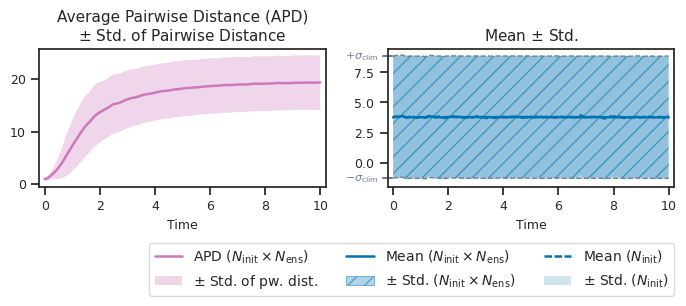

In [21]:
k = None
plot_perfect = True
show_total_var = True
show_sigma_clim = True  # Set to True to show sigma_clim reference lines

fig = plot_metrics_row_paper_ready(
    row_perturbed,
    row_perfect=row_perfect,
    k=k,
    plot_perfect=plot_perfect,
    colors=colors,
    figsize=(TEXT_WIDTH, 2.3),
    show_total_var=show_total_var,
    show_sigma_clim=show_sigma_clim,
    which_base_width="column",
    legend_cols=3,
    bbox_to_anchor=(1, 0.0),
    label_panels=False,
)
plt.show()
perfect_str = "_wperfect" if plot_perfect else ""
k_str = "avg_k" if k is None else k
show_total_var_str = "_total_var" if show_total_var else "_i_var"
show_sigma_clim_str = "_sigma_clim" if show_sigma_clim else ""

fig.savefig(
    paper_figures_dir
    / f"metrics_plot_k_{k_str}{perfect_str}{show_total_var_str}{show_sigma_clim_str}_selected.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.1,
    backend="agg",
)

In [22]:
def plot_metrics_row_all_paper_ready(
    row_perturbed,
    row_perfect=None,
    k=None,
    plot_perfect=True,
    plot_avg_j=True,
    show_sigma_clim=True,
    colors=colors,
    figsize=(16, 17),
    which_base_width="text",
    label_panels=True,
):
    sns.set_theme(
        style="white",
        rc={
            "axes.titlesize": scaled_fontsize(11, figsize[0], which_base_width),
            "axes.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "xtick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "ytick.labelsize": scaled_fontsize(9, figsize[0], which_base_width),
            "legend.fontsize": scaled_fontsize(10, figsize[0], which_base_width),
        },
    )
    sns.set_palette("colorblind")

    t = _t_axis(row_perturbed)

    # -----------------------
    # perturbed metrics
    # -----------------------
    mean_p = _sel_tk(row_perturbed["mean_total_tk"], k)  # over (i,j)
    std_p_i = _sel_tk(row_perturbed["std_i_tk"], k)  # over i
    med_p_i = _sel_tk(row_perturbed["median_i_tk"], k)
    q25_p_i = _sel_tk(row_perturbed["q25_i_tk"], k)
    q75_p_i = _sel_tk(row_perturbed["q75_i_tk"], k)

    std_p_total = _sel_tk(row_perturbed["std_total_tk"], k)  # over (i,j)
    med_total_p = _sel_tk(row_perturbed["median_total_tk"], k)
    q25_total_p = _sel_tk(row_perturbed["q25_total_tk"], k)
    q75_total_p = _sel_tk(row_perturbed["q75_total_tk"], k)

    avgpw_p = _sel_tk(row_perturbed["avg_pairwise_i_tk"], k)
    stdpw_p = _sel_tk(row_perturbed["std_pairwise_i_tk"], k)

    # -----------------------
    # perfect metrics (optional)
    # -----------------------
    do_perfect = plot_perfect and (row_perfect is not None)
    if do_perfect:
        mean_f = _sel_tk(row_perfect["mean_i_tk"], k)
        std_f = _sel_tk(row_perfect["std_i_tk"], k)

        med_f = _sel_tk(row_perfect["median_i_tk"], k)
        q25_f = _sel_tk(row_perfect["q25_i_tk"], k)
        q75_f = _sel_tk(row_perfect["q75_i_tk"], k)

    subplot_rows = 5 if plot_avg_j else 3
    fig, axes = plt.subplots(subplot_rows, 1, figsize=figsize, sharex=True)

    # styles
    hatch_i = HATCH_I
    hatch_total = TOTAL_HATCH
    alpha_pert = 0.30
    alpha_perf = 0.18
    alpha_total = 0.30
    hatch_alpha = 0.55

    c_mean = colors("mean_i_tk")
    c_median = colors("median_i_tk")
    c_pw = colors("avg_pairwise_i_tk")

    ax_idx = 0

    # ======================================================
    # 0) Avg pairwise ± Std(pairwise) (perturbed hatched)
    # ======================================================
    ax = axes[ax_idx]
    ax_idx += 1

    (line_p,) = ax.plot(
        t,
        avgpw_p,
        color=c_pw,
        # label=parse_label("avg_pairwise_i_tk", "perturbed"),
        label=r"APD $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$",
        **_PERTURBED_STYLE,
    )
    ax.fill_between(
        t, avgpw_p - stdpw_p, avgpw_p + stdpw_p, **_band_fill_kwargs(c_pw, alpha_pert)
    )
    ax.fill_between(
        t,
        avgpw_p - stdpw_p,
        avgpw_p + stdpw_p,
        **_band_hatch_kwargs(c_pw, hatch=None, hatch_alpha=hatch_alpha),
    )

    band_p_patch = _legend_band_patch(
        c_pw,
        alpha=alpha_pert,
        hatch=None,
        hatch_alpha=None,
        # label=f"± {parse_label('std_pairwise_i_tk', 'perturbed')}",
        label=r"$\pm$ Std. of pw. dist.",
    )

    ax.set_title(
        "Average Pairwise Distance (APD)\n" + r"$\pm$ Std. of Pairwise Distance"
    )
    ax.set_xlabel("Time")
    ax.legend(handles=[line_p, band_p_patch], bbox_to_anchor=(1.02, 1.02), frameon=True)

    # ======================================================
    # 1) (optional) Mean ± Std over i (perturbed hatched, perfect not)
    # ======================================================

    if plot_avg_j:
        ax = axes[ax_idx]
        ax_idx += 1

        (line_p,) = ax.plot(
            t,
            mean_p,
            color=c_mean,
            label=parse_label("mean_total_tk", "perturbed"),
            **_PERTURBED_STYLE,
        )
        ax.fill_between(
            t,
            mean_p - std_p_i,
            mean_p + std_p_i,
            **_band_fill_kwargs(c_mean, alpha_pert),
        )
        ax.fill_between(
            t,
            mean_p - std_p_i,
            mean_p + std_p_i,
            **_band_hatch_kwargs(c_mean, hatch=hatch_i, hatch_alpha=hatch_alpha),
        )

        band_p_patch = _legend_band_patch(
            c_mean,
            alpha=alpha_pert,
            hatch=hatch_i,
            hatch_alpha=hatch_alpha,
            label=f"± {parse_label('std_i_tk', 'perturbed')}",
        )
        handles = [line_p, band_p_patch]

        if do_perfect:
            (line_f,) = ax.plot(
                t,
                mean_f,
                color=c_mean,
                label=parse_label("mean_i_tk", "perfect"),
                **_PERFECT_STYLE,
            )
            ax.fill_between(
                t,
                mean_f - std_f,
                mean_f + std_f,
                **_band_fill_kwargs(c_mean, alpha_perf),
            )
            band_f_patch = _legend_band_patch(
                c_mean,
                alpha=alpha_perf,
                hatch=None,
                label=f"± {parse_label('std_i_tk', 'perfect')}",
            )
            handles += [line_f, band_f_patch]

        ax.set_title(r"Mean $\pm$ Std. over initial states")
        ax.legend(handles=handles, bbox_to_anchor=(1.02, 1.02), frameon=True)

    # ======================================================
    # 3) (optional) Median with IQR band over i (perturbed hatched, perfect not)
    # ======================================================

    if plot_avg_j:
        ax = axes[ax_idx]
        ax_idx += 1

        (line_p,) = ax.plot(
            t,
            med_p_i,
            color=c_median,
            label=parse_label("median_i_tk", "perturbed"),
            **_PERTURBED_STYLE,
        )
        ax.fill_between(t, q25_p_i, q75_p_i, **_band_fill_kwargs(c_median, alpha_pert))
        ax.fill_between(
            t,
            q25_p_i,
            q75_p_i,
            **_band_hatch_kwargs(c_median, hatch=hatch_i, hatch_alpha=hatch_alpha),
        )

        band_p_patch = _legend_band_patch(
            c_median,
            alpha=alpha_pert,
            hatch=hatch_i,
            hatch_alpha=hatch_alpha,
            label=parse_label("iqr_i_tk", "perturbed"),
        )
        handles = [line_p, band_p_patch]

        if do_perfect:
            (line_f,) = ax.plot(
                t,
                med_f,
                color=c_median,
                label=parse_label("median_i_tk", "perfect"),
                **_PERFECT_STYLE,
            )
            ax.fill_between(t, q25_f, q75_f, **_band_fill_kwargs(c_median, alpha_perf))
            band_f_patch = _legend_band_patch(
                c_median,
                alpha=alpha_perf,
                hatch=None,
                label=parse_label("iqr_i_tk", "perfect"),
            )
            handles += [line_f, band_f_patch]

        ax.set_title(r"Median with IQR band over initial states")
        ax.legend(handles=handles, bbox_to_anchor=(1.02, 1.02), frameon=True)

    # ======================================================
    # 4) Mean ± Total Std (perturbed cross-hatched, perfect not)
    # ======================================================
    ax = axes[ax_idx]
    ax_idx += 1

    # ======================================================
    # Plot sigma clim reference lines in panel 2 (Mean ± Std over i), if enabled
    if show_sigma_clim:
        sigma_clim = 5.07
        sc_color = "slategray"
        sigma_clim_line_p = mean_p + sigma_clim
        lw = 1.0
        (line_sigma_clim,) = ax.plot(
            t,
            sigma_clim_line_p,
            color=sc_color,
            linestyle="--",
            alpha=1.0,
            linewidth=lw,
            label=r"Mean $(N_{\mathrm{init}} \times N_{\mathrm{ens}}) \pm \sigma_{\mathrm{clim}}$",
        )
        sigma_clim_line_m = mean_p - sigma_clim
        ax.plot(
            t,
            sigma_clim_line_m,
            color=sc_color,
            linestyle="--",
            linewidth=lw,
            alpha=1.0,
        )

        # blended transform: x in axes coords, y in data coords
        trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)

        # x-position slightly left of the axis
        x_text = -0.03  # -0.04
        x_tick0 = -0.015
        x_tick1 = 0.015

        # upper bound
        y_upper = (mean_p + sigma_clim)[0]  # left side value

        ax.plot(
            [x_tick0, x_tick1],
            [y_upper, y_upper],
            transform=trans,
            color=sc_color,
            lw=1.5,
            clip_on=False,
        )

        ax.text(
            x_text,
            y_upper + 0.03,
            r"$+\sigma_{\mathrm{clim}}$",
            transform=trans,
            ha="right",
            va="center",
            fontsize=scaled_fontsize(8, figsize[0], which_base_width),
            color=sc_color,
            clip_on=False,
        )

        # lower bound
        y_lower = (mean_p - sigma_clim)[0]

        ax.plot(
            [x_tick0, x_tick1],
            [y_lower, y_lower],
            transform=trans,
            color=sc_color,
            lw=1.5,
            clip_on=False,
        )

        ax.text(
            x_text,
            y_lower - 0.04,
            r"$-\sigma_{\mathrm{clim}}$",
            transform=trans,
            ha="right",
            va="center",
            fontsize=scaled_fontsize(8, figsize[0], which_base_width),
            color=sc_color,
            clip_on=False,
        )

    # ======================================================

    (line_p,) = ax.plot(
        t,
        mean_p,
        color=c_mean,
        # label=parse_label("mean_total_tk", "perturbed"),
        label=r"Mean $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$",
        **_PERTURBED_STYLE,
    )
    ax.fill_between(
        t,
        mean_p - std_p_total,
        mean_p + std_p_total,
        **_band_fill_kwargs(c_mean, alpha_total),
    )
    ax.fill_between(
        t,
        mean_p - std_p_total,
        mean_p + std_p_total,
        **_band_hatch_kwargs(c_mean, hatch=hatch_total, hatch_alpha=hatch_alpha),
    )

    band_p_patch = _legend_band_patch(
        c_mean,
        alpha=alpha_total,
        hatch=hatch_total,
        hatch_alpha=hatch_alpha,
        # label=f"± {parse_label('std_i_tk', 'perturbed')}",
        label=r"$\pm$ Std. $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$",
    )
    handles = [line_p, band_p_patch]

    if do_perfect:
        (line_f,) = ax.plot(
            t,
            mean_f,
            color=c_mean,
            # label=parse_label("mean_i_tk", "perfect"),
            label=r"Mean $(N_{\mathrm{init}})$",
            **_PERFECT_STYLE,
        )
        ax.fill_between(
            t, mean_f - std_f, mean_f + std_f, **_band_fill_kwargs(c_mean, alpha_perf)
        )
        band_f_patch = _legend_band_patch(
            c_mean,
            alpha=alpha_perf,
            hatch=None,
            # label=f"± {parse_label('std_i_tk', 'perfect')}",
            label=r"$\pm$ Std. $(N_{\mathrm{init}})$",
        )
        handles += [line_f, band_f_patch]

    ax.set_title(r"Mean $\pm$ Std.")
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1.02), frameon=True)

    # ======================================================
    # 4) Median ± Total IQR (perturbed cross-hatched, perfect not)
    # ======================================================
    ax = axes[ax_idx]
    ax_idx += 1

    (line_p,) = ax.plot(
        t,
        med_total_p,
        color=c_median,
        # label=parse_label("median_total_tk", "perturbed"),
        label=r"Median $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$",
        **_PERTURBED_STYLE,
    )
    ax.fill_between(
        t, q25_total_p, q75_total_p, **_band_fill_kwargs(c_median, alpha_total)
    )
    ax.fill_between(
        t,
        q25_total_p,
        q75_total_p,
        **_band_hatch_kwargs(c_median, hatch=hatch_total, hatch_alpha=hatch_alpha),
    )

    band_p_patch = _legend_band_patch(
        c_median,
        alpha=alpha_total,
        hatch=hatch_total,
        hatch_alpha=hatch_alpha,
        # label=f"± {parse_label('iqr_total_tk', 'perturbed')}",
        label=r"$\pm$ IQR $(N_{\mathrm{init}} \times N_{\mathrm{ens}})$",
    )
    handles = [line_p, band_p_patch]

    if do_perfect:
        (line_f,) = ax.plot(
            t,
            med_f,
            color=c_median,
            # label=parse_label("median_i_tk", "perfect"),
            label=r"Median $(N_{\mathrm{init}})$",
            **_PERFECT_STYLE,
        )
        ax.fill_between(t, q25_f, q75_f, **_band_fill_kwargs(c_median, alpha_perf))
        band_f_patch = _legend_band_patch(
            c_median,
            alpha=alpha_perf,
            hatch=None,
            # label=f"± {parse_label('iqr_i_tk', 'perfect')}",
            label=r"$\pm$ IQR $(N_{\mathrm{init}})$",
        )
        handles += [line_f, band_f_patch]

    ax.set_title(r"Median $\pm$ IQR band")
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1.02), frameon=True)

    # panel labels
    panel_labels = ["a)", "b)", "c)", "d)", "e)"] if plot_avg_j else ["a)", "b)", "c)"]
    for i, ax in enumerate(axes):
        ax.grid(False)
        ax.tick_params(bottom=True, left=True)
        ax.margins(x=0.02)
        if label_panels:
            ax.text(
                0.02,
                0.95,
                panel_labels[i],
                fontsize=scaled_fontsize(11, figsize[0], which_base_width),
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontweight="normal",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.5,
                    boxstyle="round,pad=0.2",
                ),
            )

    plt.tight_layout()
    return fig

In [23]:
# different hatches when plotting both *_total_tk and *_i_tk
HATCH_I = "\\"
TOTAL_HATCH = "//"

Scaled fontsize: 9.166666666666668
Scaled fontsize: 7.5
Scaled fontsize: 7.5
Scaled fontsize: 7.5
Scaled fontsize: 8.333333333333334
Scaled fontsize: 6.666666666666667
Scaled fontsize: 6.666666666666667


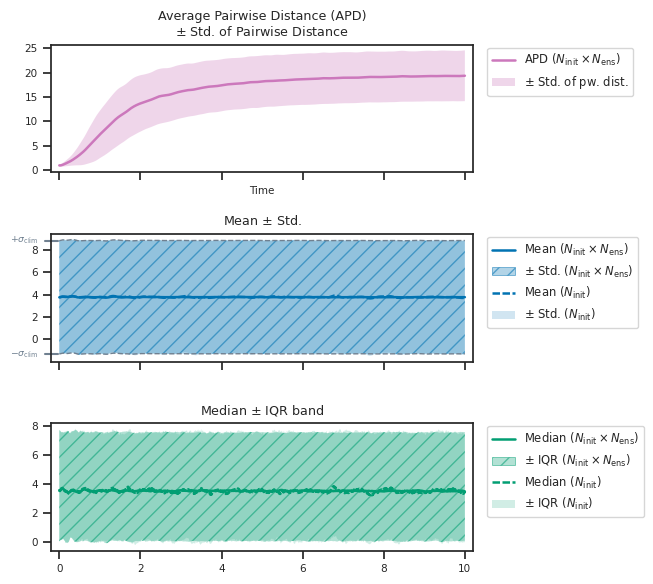

In [24]:
k = None
plot_perfect = True
plot_avg_j = False
show_sigma_clim = True  # Set to True to show sigma_clim reference lines

fig = plot_metrics_row_all_paper_ready(
    row_perturbed,
    row_perfect=row_perfect,
    k=k,
    plot_perfect=plot_perfect,
    plot_avg_j=plot_avg_j,
    colors=colors,
    figsize=(TEXT_WIDTH, 6),
    show_sigma_clim=show_sigma_clim,
    which_base_width="text",
    label_panels=False,
)
plt.show()
perfect_str = "_wperfect" if plot_perfect else ""
k_str = "avg_k" if k is None else k
plot_avg_j_str = "_avg_j" if plot_avg_j else ""
show_sigma_clim_str = "_sigma_clim" if show_sigma_clim else ""

fig.savefig(
    paper_figures_dir
    / f"metrics_plot_k_{k_str}{perfect_str}{plot_avg_j_str}{show_sigma_clim_str}.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.01,
    backend="agg",
)